In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import pylab
from PIL import Image
from math import e
import astropy.io.fits as pf
from astropy.io import fits

## Load an image and apply an optional taper

(533, 400, 3)
(399, 399)


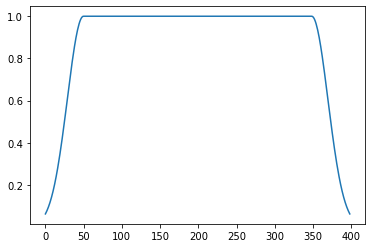

In [18]:
image = Image.open("Sorento.jpg")
image_arr = np.array(image)

x, y = np.meshgrid(np.linspace(-200,200,399), np.linspace(-200,200,399))
r = np.sqrt(x**2+y**2)

fwhm = 50.
taper = np.exp(-4*np.log(2)*((r-150)**2)/fwhm**2)
taper[np.where(r<=150)] = 1
plt.plot(taper[:,200])

print(image_arr.shape)
image_bw = image_arr[50:449,0:399,0]*taper
print(image_bw.shape)

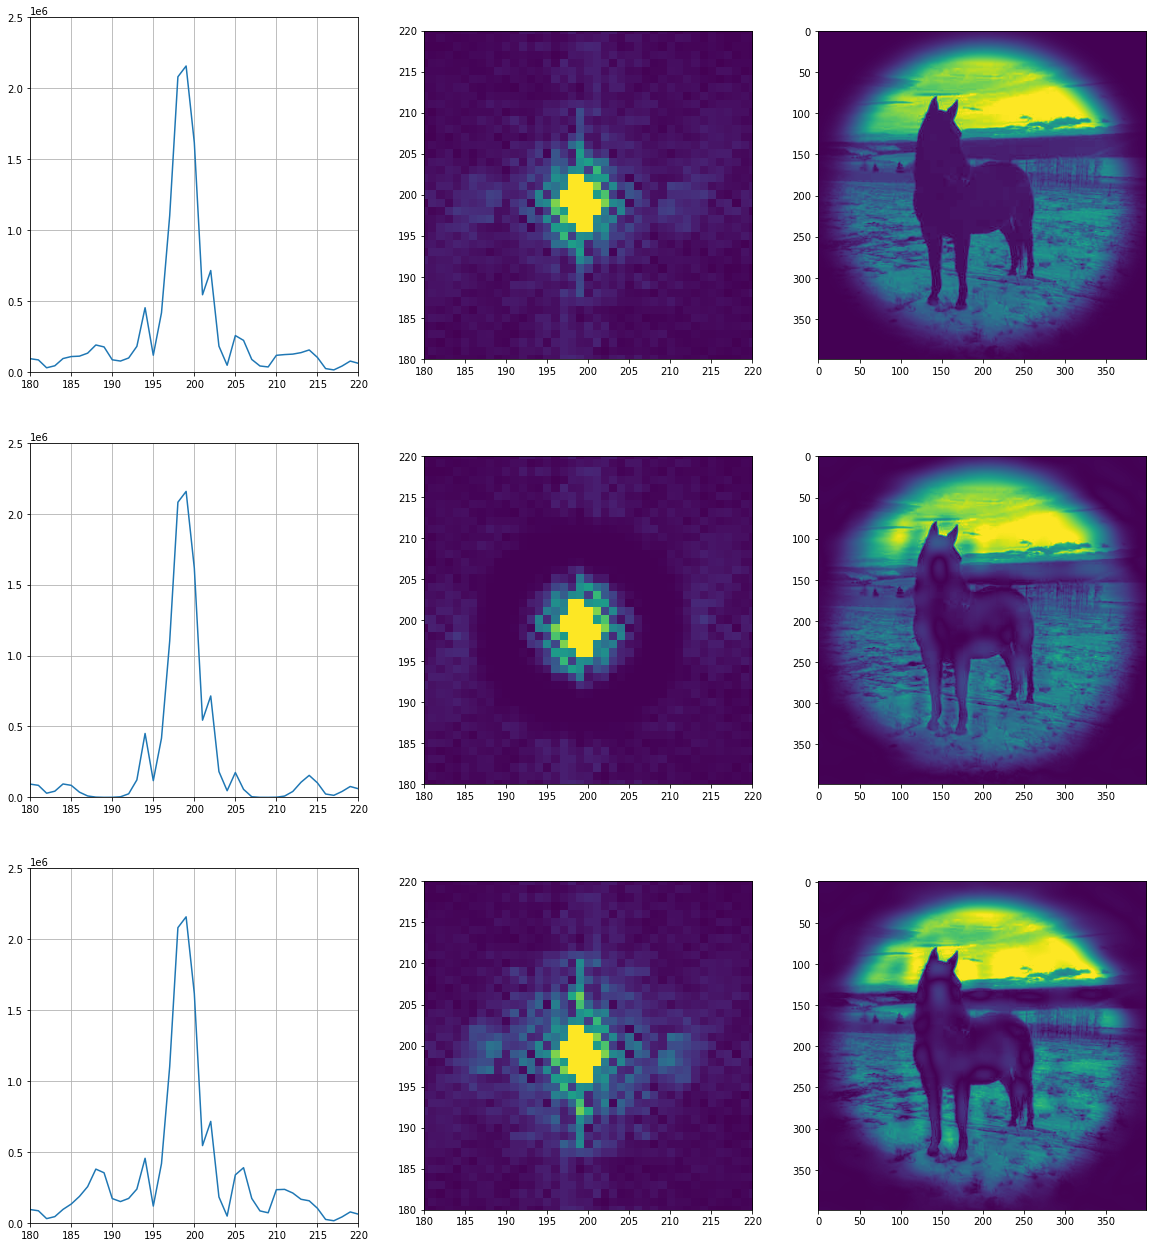

In [113]:
r1 = 5
r2 = 15

mask1 = np.exp(-4*np.log(2)*((r-r1)**2)/3**2)
mask2 = np.exp(-4*np.log(2)*((r-r2)**2)/3**2)
mask = mask1+mask2
mask[np.where(r<r1)] = 1
mask[np.where(r>r2)] = 1

image_FFT = np.fft.fft2(image_bw)

f = plt.figure(figsize=(20,30))

image_FFT_shift = np.fft.fftshift(image_FFT)
image_IFFT = np.fft.ifft2(image_FFT_shift)
plt.subplot(431),plt.plot(abs(image_FFT_shift[200,:])),plt.grid(),plt.xlim(180,220),plt.ylim(0,2.5e6)
plt.subplot(432),plt.imshow(abs(image_FFT_shift),vmin=0,vmax=1e6),plt.xlim(180,220),plt.ylim(180,220)
plt.subplot(433),plt.imshow(abs(image_IFFT),vmin=0,vmax=250)

image_FFT_shift = np.fft.fftshift(image_FFT)*mask
image_IFFT = np.fft.ifft2(image_FFT_shift)
plt.subplot(434),plt.plot(abs(image_FFT_shift[200,:])),plt.grid(),plt.xlim(180,220),plt.ylim(0,2.5e6)
plt.subplot(435),plt.imshow(abs(image_FFT_shift),vmin=0,vmax=1e6),plt.xlim(180,220),plt.ylim(180,220)
plt.subplot(436),plt.imshow(abs(image_IFFT),vmin=0,vmax=250)

mask[np.where((r>=r1) & (r<=r2))] = (-mask[np.where((r>=r1) & (r<=r2))]+2.)
image_FFT_shift = np.fft.fftshift(image_FFT)*mask
#image_FFT_shift[np.where((r>=r1) & (r<=r2))] = 5e5
image_IFFT = np.fft.ifft2(image_FFT_shift)
#plt.subplot(437),plt.plot(mask[200,:]),plt.grid(),plt.xlim(180,220)
plt.subplot(437),plt.plot(abs(image_FFT_shift[200,:])),plt.grid(),plt.xlim(180,220),plt.ylim(0,2.5e6)
plt.subplot(438),plt.imshow(abs(image_FFT_shift),vmin=0,vmax=1e6),plt.xlim(180,220),plt.ylim(180,220)
plt.subplot(439),plt.imshow(abs(image_IFFT),vmin=0,vmax=250)

plt.show()